### Import packages

In [1]:
import pandas as pd
from pathlib import Path
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

### Define paths and load data

In [2]:
# Define project and data paths
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
DATA_DIR = PROJECT_ROOT / "data/cleaned"

sci_fi_data_path = DATA_DIR / "sci_fi_stories_cleaned.jsonl"
romance_data_path = DATA_DIR / "romance_stories_cleaned.jsonl"
literary_fiction_data_path = DATA_DIR / "lit_fiction_stories_cleaned.jsonl"

In [3]:
def load_jsonl(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

In [4]:
lit_fic_stories = load_jsonl(literary_fiction_data_path)
romance_stories = load_jsonl(romance_data_path)
sci_fi_stories = load_jsonl(sci_fi_data_path)

### Functions

In [5]:
# function to count occurrences of "he" and "she" in the stories
def count_he_and_she(stories):
    total_he = 0
    total_she = 0

    for item in stories:
        text = item["story"].lower()
        total_he += len(re.findall(r"\bhe\b", text))
        total_she += len(re.findall(r"\bshe\b", text))

    return total_he, total_she

In [6]:
# function to build a long-format DataFrame for gender counts
def build_gender_count_df_long(story_groups, groupby_variable):
    rows = []

    for stories, label in story_groups:
        he_count, she_count = count_he_and_she(stories)

        rows.append({
            groupby_variable: label,
            "Pronoun": "he",
            "Count": he_count
        })

        rows.append({
            groupby_variable: label,
            "Pronoun": "she",
            "Count": she_count
        })

    return pd.DataFrame(rows)

In [7]:
# function to split stories into groups based on "agent_type"
def split_stories_for_plotting_agent_type(stories):
    mapping = {
        "occupational_masculine_stereotyped": "Male Occ. Stereotype",
        "occupational_feminine_stereotyped": "Female Occ. Stereotype",
        "occupational_neutral": "Neutral Occupational",
        "non_occupational": "Non-Occupational"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("agent_type") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [8]:
# function to split stories into groups based on "event_valence"
def split_stories_for_plotting_event_type(stories):
    mapping = {
        "positive": "Positive Valence",
        "negative": "Negative Valence",
        "neutral": "Neutral Valence"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("event_valence") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [9]:
# function to split stories into groups based on "context_valence"
def split_stories_for_plotting_context_type(stories):
    mapping = {
        "positive": "Positive Valence",
        "negative": "Negative Valence",
        "neutral": "Neutral Valence"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("context_valence") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [10]:
# function to plot the percentages of "he" and "she" for each group
def plot_he_she_percentages(df_counts, genre_label, groupby_variable, ax):
    
    df_percent = df_counts.copy()

    df_percent["Percent"] = (
        df_percent["Count"] /
        df_percent.groupby(groupby_variable)["Count"].transform("sum")
    ) * 100

    sns.barplot(
        x=groupby_variable,
        y="Percent",
        hue="Pronoun",
        data=df_percent,
        palette=["lightblue", "darkred"],
        ax=ax
    )

    ax.set_title(f"{groupby_variable}", fontsize=16)
    ax.set_xlabel(None)
    ax.set_ylabel("Percentage (%)", fontsize=16)
    ax.tick_params(axis="x", rotation=45, labelsize=14)

### Build gender count dataframe

In [11]:
story_groups_lit_fiction_agent = split_stories_for_plotting_agent_type(lit_fic_stories)
df_counts_lit_fiction_agent = build_gender_count_df_long(story_groups_lit_fiction_agent, groupby_variable="Agent Type")

story_groups_romance_agent = split_stories_for_plotting_agent_type(romance_stories)
df_counts_romance_agent = build_gender_count_df_long(story_groups_romance_agent, groupby_variable="Agent Type")

story_groups_sci_fi_agent = split_stories_for_plotting_agent_type(sci_fi_stories)
df_counts_sci_fi_agent = build_gender_count_df_long(story_groups_sci_fi_agent, groupby_variable="Agent Type")

story_groups_lit_fiction_event = split_stories_for_plotting_event_type(lit_fic_stories)
df_counts_lit_fiction_event = build_gender_count_df_long(story_groups_lit_fiction_event, groupby_variable="Event Valence")

story_groups_romance_event = split_stories_for_plotting_event_type(romance_stories)
df_counts_romance_event = build_gender_count_df_long(story_groups_romance_event, groupby_variable="Event Valence")

story_groups_sci_fi_event = split_stories_for_plotting_event_type(sci_fi_stories)
df_counts_sci_fi_event = build_gender_count_df_long(story_groups_sci_fi_event, groupby_variable="Event Valence")

story_groups_lit_fiction_context = split_stories_for_plotting_context_type(lit_fic_stories)
df_counts_lit_fiction_context = build_gender_count_df_long(story_groups_lit_fiction_context, groupby_variable="Context Valence")

story_groups_romance_context = split_stories_for_plotting_context_type(romance_stories)
df_counts_romance_context = build_gender_count_df_long(story_groups_romance_context, groupby_variable="Context Valence")

story_groups_sci_fi_context = split_stories_for_plotting_context_type(sci_fi_stories)
df_counts_sci_fi_context = build_gender_count_df_long(story_groups_sci_fi_context, groupby_variable="Context Valence")

### Literary Fiction

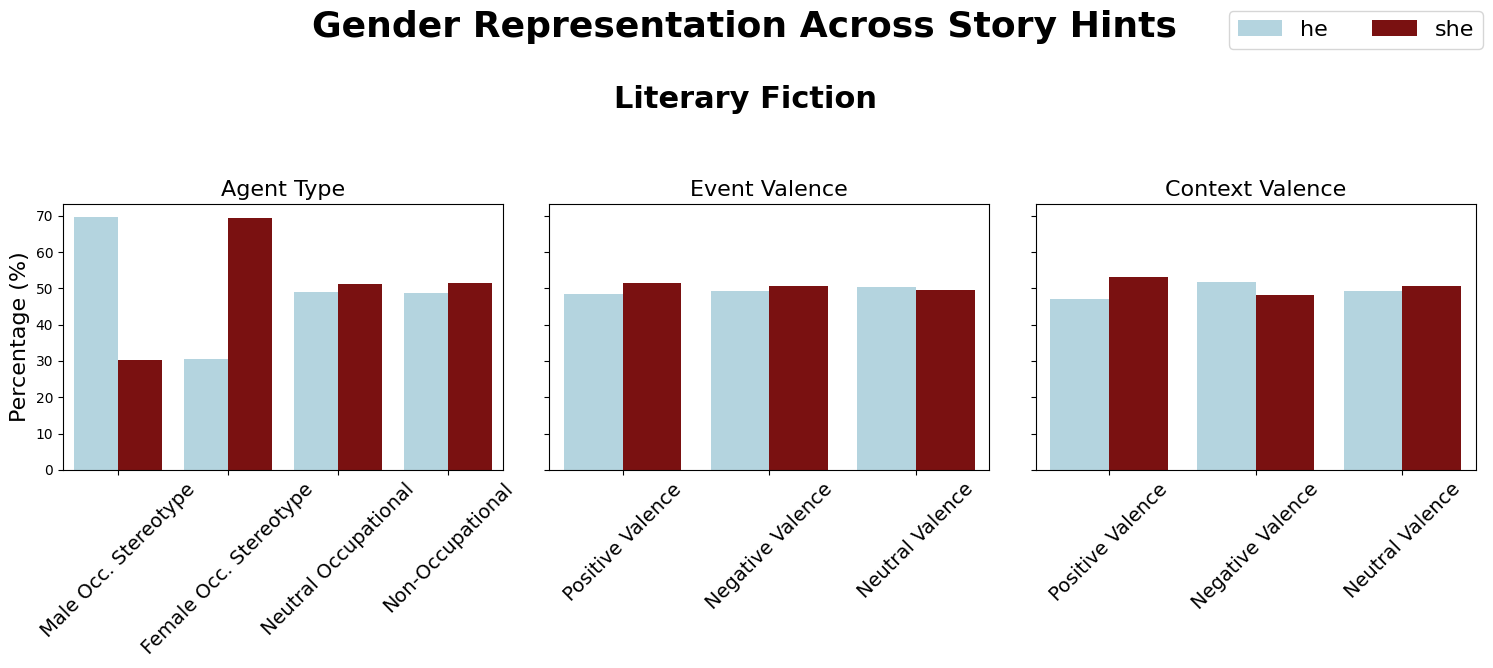

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=True)

plot_he_she_percentages(df_counts_lit_fiction_agent,
                        "Literary Fiction",
                        "Agent Type",
                        axes[0])

plot_he_she_percentages(df_counts_lit_fiction_event,
                        "Literary Fiction",
                        "Event Valence",
                        axes[1])

plot_he_she_percentages(df_counts_lit_fiction_context,
                        "Literary Fiction",
                        "Context Valence",
                        axes[2])

# Top-level title
fig.text(0.5, 1.06, "Gender Representation Across Story Hints",
         ha='center', fontsize=26, fontweight='bold')

# Existing suptitle (now acts like a subtitle)
fig.suptitle("Literary Fiction",
             fontsize=22, fontweight='bold')

for ax in axes:
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper right',
           ncol=len(labels), fontsize=16, frameon=True)

plt.tight_layout(rect=[0,0,1,0.92])
plt.show()

### Romance

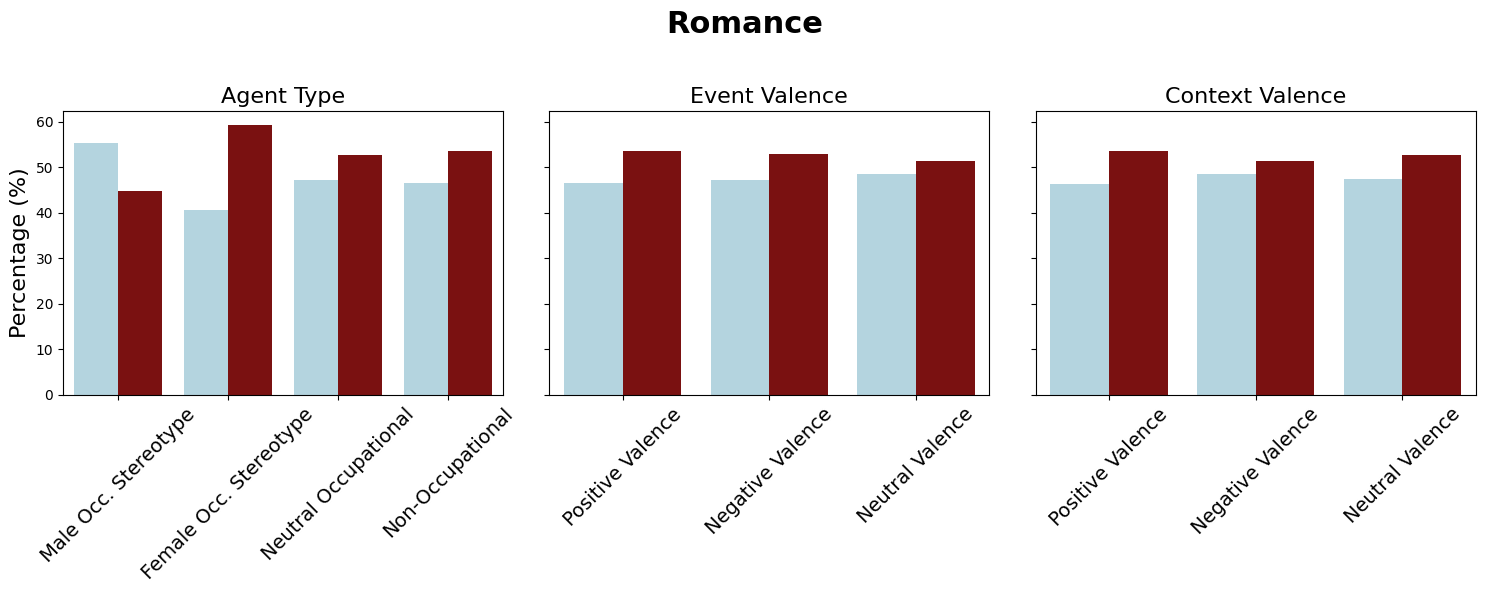

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=True)

plot_he_she_percentages(df_counts_romance_agent,
                        "Romance",
                        "Agent Type",
                        axes[0])

plot_he_she_percentages(df_counts_romance_event,
                        "Romance",
                        "Event Valence",
                        axes[1])

plot_he_she_percentages(df_counts_romance_context,
                        "Romance",
                        "Context Valence",
                        axes[2])

fig.suptitle("Romance",
             fontsize=22,
             fontweight="bold")

for ax in axes:
    ax.get_legend().remove()  # remove the subplot legend

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

### Sci-fi

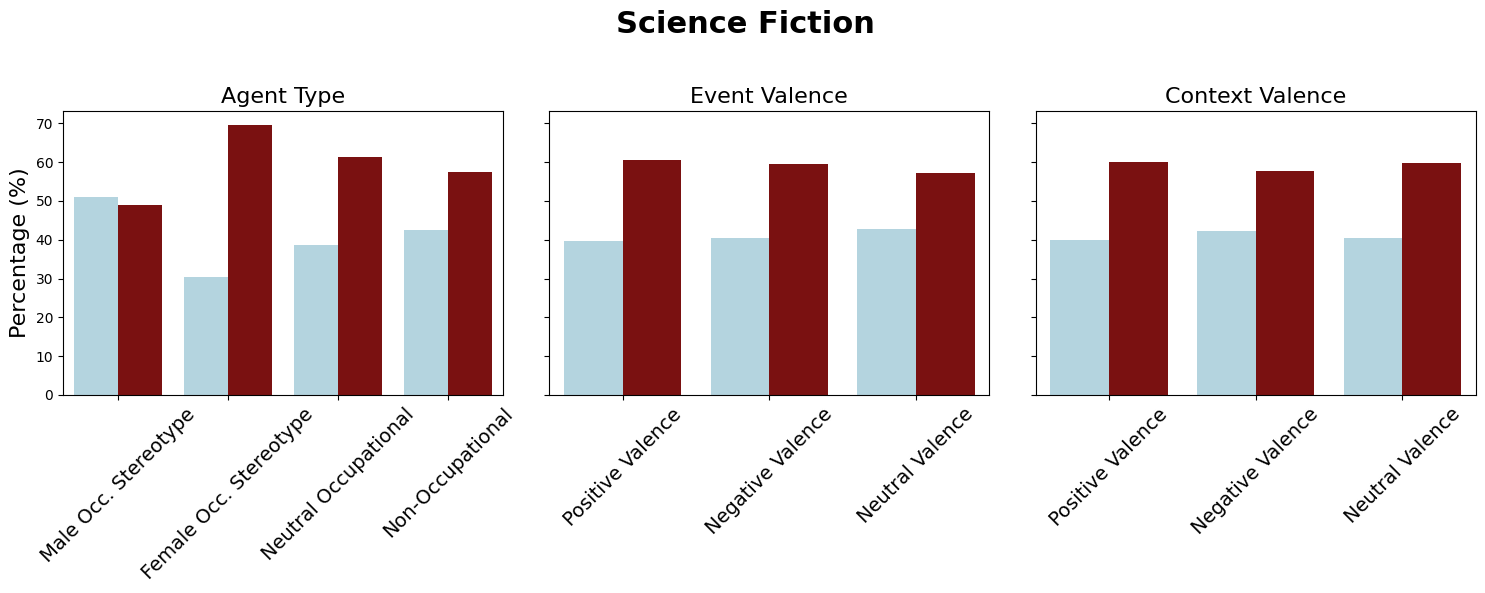

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=True)

plot_he_she_percentages(df_counts_sci_fi_agent,
                        "Science Fiction",
                        "Agent Type",
                        axes[0])

plot_he_she_percentages(df_counts_sci_fi_event,
                        "Science Fiction",
                        "Event Valence",
                        axes[1])

plot_he_she_percentages(df_counts_sci_fi_context,
                        "Science Fiction",
                        "Context Valence",
                        axes[2])

fig.suptitle("Science Fiction",
             fontsize=22,
             fontweight="bold")

for ax in axes:
    ax.get_legend().remove()  # remove the subplot legend

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

### Overall he and she frequency

In [15]:
# make a dataframe of the counts and percentages of "he" and "she" for each genre
he_and_she_counts = {
    "Genre": ["Literary Fiction", "Romance", "Science Fiction"],
    "he": [count_he_and_she(lit_fic_stories)[0],
           count_he_and_she(romance_stories)[0],
           count_he_and_she(sci_fi_stories)[0]],
    "she": [count_he_and_she(lit_fic_stories)[1],
           count_he_and_she(romance_stories)[1],
           count_he_and_she(sci_fi_stories)[1]]
}

he_and_she_counts_df = pd.DataFrame(he_and_she_counts)

In [16]:
# change to long format for plotting
he_and_she_counts_long = he_and_she_counts_df.melt(id_vars="Genre", var_name="Pronoun", value_name="Count")

In [17]:
# add percentage for each genre
he_and_she_counts_long["Percent"] = (
    he_and_she_counts_long["Count"] /
    he_and_she_counts_long.groupby("Genre")["Count"].transform("sum")
) * 100

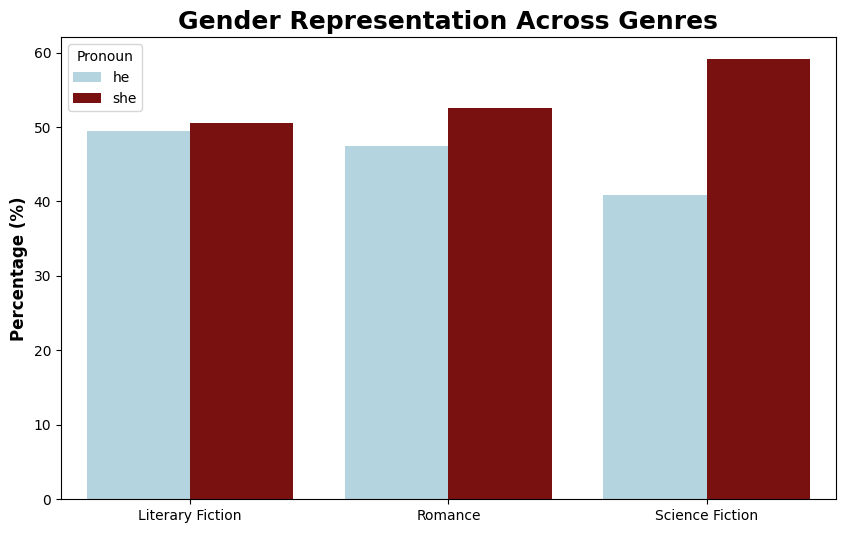

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Genre",
    y="Percent",
    hue="Pronoun",
    data=he_and_she_counts_long,
    palette=["lightblue", "darkred"]
    )
plt.title("Gender Representation Across Genres", fontsize=18, fontweight="bold")
plt.xlabel(None)
plt.ylabel("Percentage (%)", fontweight="bold", fontsize=12)
plt.legend(title="Pronoun", loc='upper left')
plt.show()

In [29]:
df_counts_sci_fi_agent["Percentage"] = (
df_counts_sci_fi_agent["Count"] /
df_counts_sci_fi_agent.groupby("Agent Type")["Count"].transform("sum") * 100)

In [30]:
df_counts_sci_fi_agent

,Agent Type,Pronoun,Count,Percentage
0,Male Occ. Stereotype,he,35334,51.110918
1,Male Occ. Stereotype,she,33798,48.889082
2,Female Occ. Stereotype,he,19397,30.375207
3,Female Occ. Stereotype,she,44461,69.624793
4,Neutral Occupational,he,25505,38.725498
5,Neutral Occupational,she,40356,61.274502
6,Non-Occupational,he,28576,42.523810
7,Non-Occupational,she,38624,57.476190
